## Idea

Train the final XGBoost model on the complete training dataset using the
hyperparameters selected through SGKF tuning, then perform the final evaluation
once on the untouched test dataset.

---

### Imports

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.xgboost

import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
				confusion_matrix,
				ConfusionMatrixDisplay,
				precision_recall_curve,
				roc_curve
)

### Paths + MLFlow

In [4]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v5.parquet"
TEST_PATH = DATA_PATH / "dvc" / "test_v5.parquet"

BEST_PARAMS_PATH = (
    DATA_PATH
    / "results"
    / "best_xgb_params_v5.json"
)

mlflow.set_tracking_uri(
    f"file:{PROJECT_ROOT / 'mlruns'}"
)

mlflow.set_experiment(
    "simbox_fraud_detection_v5"
)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/479133145194050450', creation_time=1786138842469, experiment_id='479133145194050450', last_update_time=1786138842469, lifecycle_stage='active', name='simbox_fraud_detection_v5', tags={}, trace_location=None, workspace='default'>

---

### Load datasets

In [5]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

train_df["profile_date"] = pd.to_datetime(train_df["profile_date"])
test_df["profile_date"] = pd.to_datetime(test_df["profile_date"])

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

print(
    f"Train period: "
    f"{train_df['profile_date'].min()} → "
    f"{train_df['profile_date'].max()}"
)

print(
    f"Test period: "
    f"{test_df['profile_date'].min()} → "
    f"{test_df['profile_date'].max()}"
)

Train shape: (314610, 26)
Test shape:  (114190, 26)
Train period: 2022-11-01 00:00:00 → 2022-11-11 00:00:00
Test period: 2022-11-12 00:00:00 → 2022-11-15 00:00:00


### Prepare feature set

In [6]:
REMOVED_FEATURES = [
    "nb_distinct_lacs",
    "ratio_distinct_lacs_vs_out"
]

IDENTIFIER_COLUMNS = [
    "msisdn",
    "profile_date",
    "label"
]

FEATURES = [
    c for c in train_df.columns
    if c not in IDENTIFIER_COLUMNS + REMOVED_FEATURES
]

X_train = train_df[FEATURES]
y_train = train_df["label"]

X_test = test_df[FEATURES]
y_test = test_df["label"]

print(f"Number of features: {len(FEATURES)}")
print(FEATURES)

Number of features: 21
['nb_out_calls', 'nb_in_calls', 'nb_called_numbers', 'avg_out_duration', 'avg_in_duration', 'ratio_in_vs_out', 'ratio_distinct_vs_out', 'ratio_in_duration_vs_out_duration', 'dawn_count', 'day_count', 'afternoon_count', 'night_count', 'ratio_dawn_vs_out', 'ratio_day_vs_out', 'ratio_afternoon_vs_out', 'ratio_night_vs_out', 'nb_flagged_calls', 'ratio_flagged_vs_out', 'nb_distinct_cell_ids', 'ratio_distinct_cell_ids_vs_out', 'avg_delay_per_day']


---

### Load tuned hyperparameters

In [7]:
with open(BEST_PARAMS_PATH, "r") as f:
    best_params = json.load(f)

print("Loaded hyperparameters:")
print(json.dumps(best_params, indent=4))

Loaded hyperparameters:
{
    "params": {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "eta": 0.061504978294216577,
        "max_depth": 4,
        "min_child_weight": 17,
        "gamma": 0.7950448826199306,
        "subsample": 0.9612316297503566,
        "colsample_bytree": 0.6450748029091332,
        "reg_alpha": 8.787729095874198,
        "reg_lambda": 9.75774664145889,
        "scale_pos_weight": 16.353963263279827,
        "seed": 42,
        "n_jobs": -1
    },
    "num_boost_round": 600
}


### Prepare final parameters

In [8]:
scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

params = best_params.copy()

params["scale_pos_weight"] = scale_pos_weight
params["objective"] = "binary:logistic"
params["eval_metric"] = "aucpr"
params["seed"] = 42
params["n_jobs"] = -1
params["verbosity"] = 0

num_boost_round = params.pop(
    "n_estimators",
    params.pop("num_boost_round", 100)
)

print("Final parameters:")
print(json.dumps(params, indent=4))
print(f"\nBoosting rounds: {num_boost_round}")
print(f"Scale pos weight: {scale_pos_weight:.4f}")

Final parameters:
{
    "params": {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "eta": 0.061504978294216577,
        "max_depth": 4,
        "min_child_weight": 17,
        "gamma": 0.7950448826199306,
        "subsample": 0.9612316297503566,
        "colsample_bytree": 0.6450748029091332,
        "reg_alpha": 8.787729095874198,
        "reg_lambda": 9.75774664145889,
        "scale_pos_weight": 16.353963263279827,
        "seed": 42,
        "n_jobs": -1
    },
    "scale_pos_weight": 16.353963263279827,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "seed": 42,
    "n_jobs": -1,
    "verbosity": 0
}

Boosting rounds: 600
Scale pos weight: 16.3540


---

### Start MLflow run

In [9]:
with mlflow.start_run(
    run_name="final_model_v5"
) as run:

    mlflow.log_params({
        "feature_count": len(FEATURES),
        "removed_features": ", ".join(REMOVED_FEATURES),
        "num_boost_round": num_boost_round,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "train_start": str(train_df["profile_date"].min()),
        "train_end": str(train_df["profile_date"].max()),
        "test_start": str(test_df["profile_date"].min()),
        "test_end": str(test_df["profile_date"].max()),
        **params
    })

    mlflow.log_dict(
        best_params,
        "tuned_hyperparameters.json"
    )

    print(f"MLflow run ID: {run.info.run_id}")

2026/08/08 22:05:27 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



MLflow run ID: 4b9097cb47074b329205b45bf3cace37


### Threshold tuning

In [10]:
threshold_validation_day = train_df["profile_date"].max()

threshold_train_df = train_df[
    train_df["profile_date"] < threshold_validation_day
]

threshold_val_df = train_df[
    train_df["profile_date"] == threshold_validation_day
]

X_threshold_train = threshold_train_df[FEATURES]
y_threshold_train = threshold_train_df["label"]

X_threshold_val = threshold_val_df[FEATURES]
y_threshold_val = threshold_val_df["label"]

threshold_scale_pos_weight = (
    (y_threshold_train == 0).sum()
    /
    (y_threshold_train == 1).sum()
)

threshold_params = params.copy()
threshold_params["scale_pos_weight"] = (
    threshold_scale_pos_weight
)

threshold_model = xgb.train(
    params=threshold_params,
    dtrain=xgb.DMatrix(
        X_threshold_train,
        label=y_threshold_train
    ),
    num_boost_round=num_boost_round
)

threshold_val_proba = threshold_model.predict(
    xgb.DMatrix(X_threshold_val)
)

# Threshold optimization
precision, recall, thresholds = precision_recall_curve(
    y_threshold_val,
    threshold_val_proba
)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (precision[:-1] + recall[:-1] + 1e-12)
)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print(f"Threshold validation day: {threshold_validation_day}")
print(f"Optimal threshold: {best_threshold:.6f}")
print(f"Validation F1: {f1_scores[best_idx]:.6f}")
print(f"Validation precision: {precision[best_idx]:.6f}")
print(f"Validation recall: {recall[best_idx]:.6f}")

Threshold validation day: 2022-11-11 00:00:00
Optimal threshold: 0.788728
Validation F1: 0.398514
Validation precision: 0.471246
Validation recall: 0.345231


### Train Final model

In [11]:
dtrain = xgb.DMatrix(
    X_train,
    label=y_train
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test
)

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round
)

print("Final model trained successfully.")

Final model trained successfully.


In [12]:
y_test_proba = model.predict(dtest)

y_test_pred_default = (
    y_test_proba >= 0.5
).astype(int)

y_test_pred_tuned = (
    y_test_proba >= best_threshold
).astype(int)

### Final predicitions

In [13]:
y_test_proba = model.predict(dtest)

y_test_pred = (
    y_test_proba >= 0.5
).astype(int)

print(f"Predictions generated: {len(y_test_pred)}")

Predictions generated: 114190


### Final evaluation

In [14]:
pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

report_default = classification_report(
    y_test,
    y_test_pred_default,
    digits=4
)

report_tuned = classification_report(
    y_test,
    y_test_pred_tuned,
    digits=4
)

print("=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

print(f"PR-AUC:  {pr_auc:.6f}")
print(f"ROC-AUC: {roc_auc:.6f}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — THRESHOLD = 0.50")
print("=" * 70)
print(report_default)

print("\n" + "=" * 70)
print(
    f"CLASSIFICATION REPORT — "
    f"THRESHOLD = {best_threshold:.6f}"
)
print("=" * 70)
print(report_tuned)

FINAL TEST RESULTS
PR-AUC:  0.380475
ROC-AUC: 0.841957

CLASSIFICATION REPORT — THRESHOLD = 0.50
              precision    recall  f1-score   support

           0     0.9720    0.8402    0.9013    107663
           1     0.1856    0.6009    0.2837      6527

    accuracy                         0.8265    114190
   macro avg     0.5788    0.7205    0.5925    114190
weighted avg     0.9271    0.8265    0.8660    114190


CLASSIFICATION REPORT — THRESHOLD = 0.788728
              precision    recall  f1-score   support

           0     0.9588    0.9742    0.9664    107663
           1     0.4209    0.3093    0.3566      6527

    accuracy                         0.9362    114190
   macro avg     0.6898    0.6418    0.6615    114190
weighted avg     0.9280    0.9362    0.9316    114190



Confusion Matrix

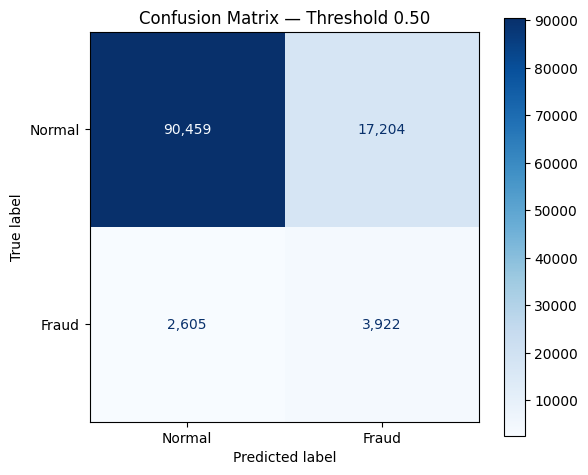

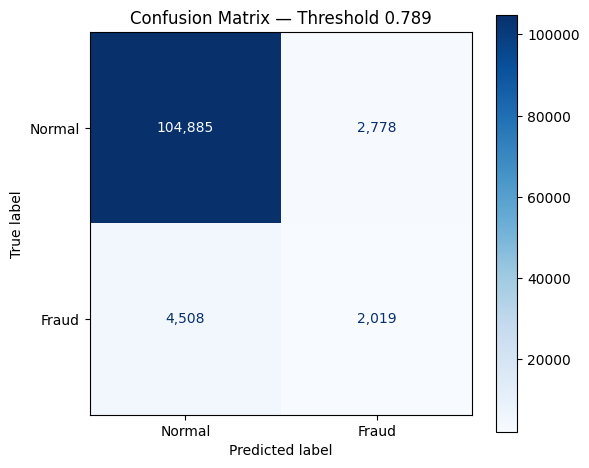

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_default = confusion_matrix(
    y_test,
    y_test_pred_default
)

cm_tuned = confusion_matrix(
    y_test,
    y_test_pred_tuned
)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=["Normal", "Fraud"]
).plot(
    ax=ax,
    cmap="Blues",
    values_format=","
)

ax.set_title("Confusion Matrix — Threshold 0.50")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Normal", "Fraud"]
).plot(
    ax=ax,
    cmap="Blues",
    values_format=","
)

ax.set_title(
    f"Confusion Matrix — Threshold {best_threshold:.3f}"
)

plt.tight_layout()
plt.show()

PR-AUC

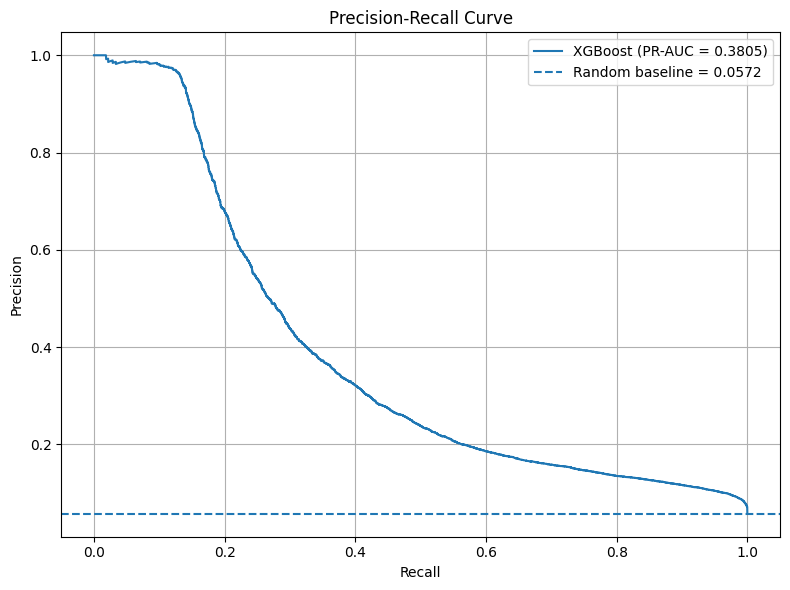

In [16]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = (
    (y_test == 1).sum()
    /
    len(y_test)
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {pr_auc:.4f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ROC-AUC

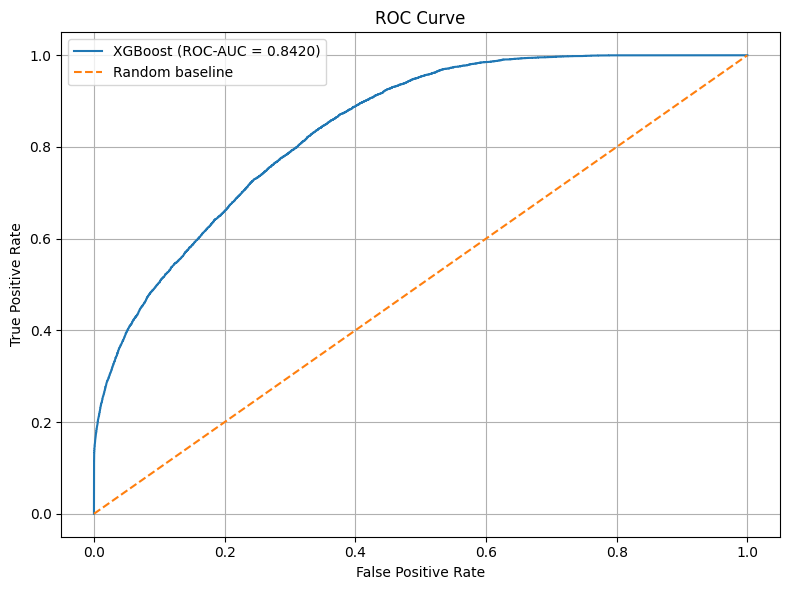

In [17]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Probability distribution

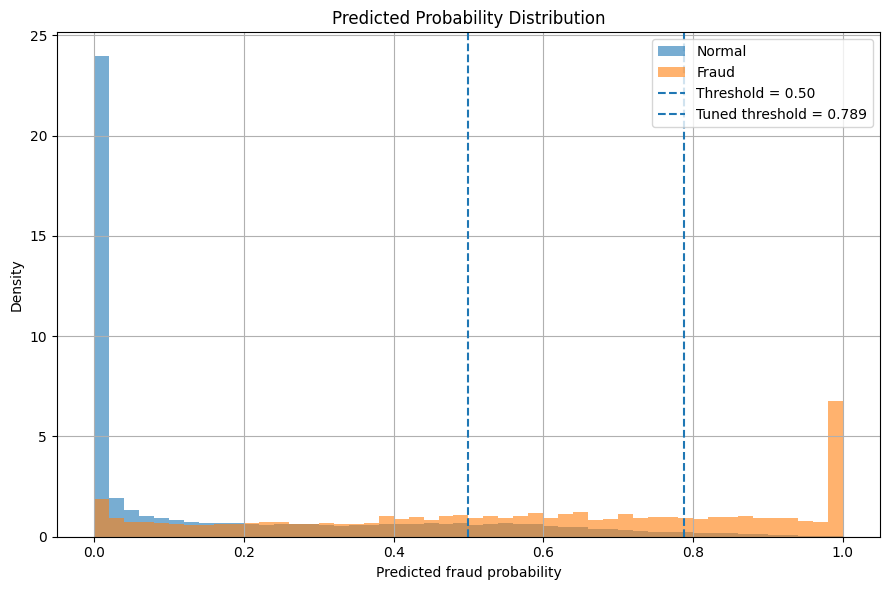

In [18]:
plt.figure(figsize=(9, 6))

plt.hist(
    y_test_proba[y_test.to_numpy() == 0],
    bins=50,
    alpha=0.6,
    density=True,
    label="Normal"
)

plt.hist(
    y_test_proba[y_test.to_numpy() == 1],
    bins=50,
    alpha=0.6,
    density=True,
    label="Fraud"
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Threshold = 0.50"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Tuned threshold = {best_threshold:.3f}"
)

plt.xlabel("Predicted fraud probability")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Log final metrics to MLflow

In [19]:
mlflow.log_metrics({
    "test_pr_auc": pr_auc,
    "test_roc_auc": roc_auc,
    "default_threshold": 0.5,
    "tuned_threshold": best_threshold
})

mlflow.log_text(
    report_default,
    "classification_report_threshold_0.5.txt"
)

mlflow.log_text(
    report_tuned,
    "classification_report_tuned_threshold.txt"
)

print("Final evaluation logged to MLflow.")

Final evaluation logged to MLflow.


---
## TEST

In [20]:
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd
import numpy as np

all_profiles = pd.read_parquet(DATA_PATH / "profiles_new_feat" / "all_profiles.parquet")

daily_results = []

for day in sorted(all_profiles["profile_date"].unique()):
    day_df = all_profiles[
        all_profiles["profile_date"] == day
    ]

    X_day = day_df[FEATURES]
    y_day = day_df["label"]

    day_proba = model.predict(
        xgb.DMatrix(X_day)
    )

    # Reproduce team lead's probability rounding
    day_proba_rounded = np.round(day_proba, 2)

    # PR-AUC
    precision, recall, _ = precision_recall_curve(
        y_day,
        day_proba_rounded
    )

    pr_auc = auc(
        recall,
        precision
    )

    # Classification at threshold = 0.88
    day_pred = (
        day_proba_rounded >= 0.88
    ).astype(int)

    accuracy = (
        day_pred == y_day.to_numpy()
    ).mean()

    tp = ((y_day.to_numpy() == 1) & (day_pred == 1)).sum()
    fp = ((y_day.to_numpy() == 0) & (day_pred == 1)).sum()
    fn = ((y_day.to_numpy() == 1) & (day_pred == 0)).sum()

    precision_088 = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall_088 = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    daily_results.append({
        "day": day,
        "samples": len(day_df),
        "fraud": int((y_day == 1).sum()),
        "fraud_ratio": (y_day == 1).mean(),
        "pr_auc": pr_auc,
        "accuracy@0.88": accuracy,
        "precision@0.88": precision_088,
        "recall@0.88": recall_088
    })

daily_results_df = pd.DataFrame(daily_results)

display(
    daily_results_df.style.format({
        "fraud_ratio": "{:.4f}",
        "pr_auc": "{:.6f}",
        "accuracy@0.88": "{:.4f}",
        "precision@0.88": "{:.4f}",
        "recall@0.88": "{:.4f}"
    })
)

,day,samples,fraud,fraud_ratio,pr_auc,accuracy@0.88,precision@0.88,recall@0.88
0,2022-11-01,28004,1540,0.0550,0.753587,0.9656,0.8439,0.4597
1,2022-11-02,28401,1646,0.0580,0.789315,0.9655,0.8476,0.4933
2,2022-11-03,28501,1662,0.0583,0.774708,0.9649,0.8598,0.4759
3,2022-11-04,28719,1658,0.0577,0.788914,0.9662,0.8736,0.4837
4,2022-11-05,28648,1639,0.0572,0.771871,0.9650,0.8795,0.4497
5,2022-11-06,28468,1563,0.0549,0.748129,0.9644,0.8303,0.4415
6,2022-11-07,28916,1674,0.0579,0.803951,0.9665,0.8667,0.4970
7,2022-11-08,28771,1676,0.0583,0.783937,0.9646,0.8500,0.4767
8,2022-11-09,28761,1691,0.0588,0.778726,0.9647,0.8537,0.4831
9,2022-11-10,28535,1671,0.0586,0.764572,0.9631,0.8360,0.4608


In [21]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
import pandas as pd
import numpy as np
import xgboost as xgb

all_profiles = pd.read_parquet(DATA_PATH / "profiles_new_feat" / "all_profiles.parquet")

walk_forward_results = []

days = sorted(all_profiles["profile_date"].unique())

for i in range(1, len(days)):
    train_days = days[:i]
    validation_day = days[i]

    train_df = all_profiles[
        all_profiles["profile_date"].isin(train_days)
    ]

    val_df = all_profiles[
        all_profiles["profile_date"] == validation_day
    ]

    X_train = train_df[FEATURES]
    y_train = train_df["label"]

    X_val = val_df[FEATURES]
    y_val = val_df["label"]

    # Recompute class weight for the current training window
    scale_pos_weight = (
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )

    current_params = params.copy()
    current_params["scale_pos_weight"] = scale_pos_weight

    model_wf = xgb.train(
        params=current_params,
        dtrain=xgb.DMatrix(
            X_train,
            label=y_train
        ),
        num_boost_round=num_boost_round
    )

    val_proba = model_wf.predict(
        xgb.DMatrix(X_val)
    )

    # PR-AUC
    precision, recall, _ = precision_recall_curve(
        y_val,
        val_proba
    )

    pr_auc = auc(
        recall,
        precision
    )

    # ROC-AUC
    roc_auc = roc_auc_score(
        y_val,
        val_proba
    )

    # Classification at threshold 0.88
    val_pred = (
        val_proba >= 0.88
    ).astype(int)

    accuracy = (
        val_pred == y_val.to_numpy()
    ).mean()

    tp = ((y_val.to_numpy() == 1) & (val_pred == 1)).sum()
    fp = ((y_val.to_numpy() == 0) & (val_pred == 1)).sum()
    fn = ((y_val.to_numpy() == 1) & (val_pred == 0)).sum()

    precision_088 = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall_088 = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    walk_forward_results.append({
        "train_period": f"{train_days[0]} → {train_days[-1]}",
        "validation_day": validation_day,
        "train_samples": len(train_df),
        "validation_samples": len(val_df),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "accuracy@0.88": accuracy,
        "precision@0.88": precision_088,
        "recall@0.88": recall_088
    })

walk_forward_results_df = pd.DataFrame(
    walk_forward_results
)

display(
    walk_forward_results_df.style.format({
        "pr_auc": "{:.6f}",
        "roc_auc": "{:.6f}",
        "accuracy@0.88": "{:.4f}",
        "precision@0.88": "{:.4f}",
        "recall@0.88": "{:.4f}"
    })
)

,train_period,validation_day,train_samples,validation_samples,pr_auc,roc_auc,accuracy@0.88,precision@0.88,recall@0.88
0,2022-11-01 → 2022-11-01,2022-11-02,28004,28401,0.351418,0.810091,0.9467,0.6220,0.2029
1,2022-11-01 → 2022-11-02,2022-11-03,56405,28501,0.357973,0.822693,0.9485,0.7004,0.2040
2,2022-11-01 → 2022-11-03,2022-11-04,84906,28719,0.359796,0.820981,0.9493,0.7014,0.2111
3,2022-11-01 → 2022-11-04,2022-11-05,113625,28648,0.322155,0.826139,0.9468,0.6432,0.1562
4,2022-11-01 → 2022-11-05,2022-11-06,142273,28468,0.311146,0.813859,0.9480,0.5913,0.1740
5,2022-11-01 → 2022-11-06,2022-11-07,170741,28916,0.394252,0.841745,0.9487,0.6610,0.2330
6,2022-11-01 → 2022-11-07,2022-11-08,199657,28771,0.375100,0.837850,0.9465,0.6183,0.2136
7,2022-11-01 → 2022-11-08,2022-11-09,228428,28761,0.390036,0.839821,0.9475,0.6591,0.2218
8,2022-11-01 → 2022-11-09,2022-11-10,257189,28535,0.387887,0.837717,0.9467,0.6218,0.2292
9,2022-11-01 → 2022-11-10,2022-11-11,285724,28886,0.421466,0.848541,0.9485,0.6627,0.2633
